# Large-Scale Overlapping Genes Analysis (Multiprocessing Version)

This notebook refines the stability landscape analysis with **parallel processing**.

**Multiprocessing Features:**
- Automatic CPU core detection
- Parallel trial execution using `multiprocessing.Pool`
- Significant speedup for large scans

**Metrics:**
1.  **Final Energy Distance (`Dist`)**: Baseline metric (Final Energy - Natural Mean).
2.  **Minimum Energy Distance (`Min_Dist`)**: The closest the simulated energy gets to the natural mean energy.
3.  **Iterations to Convergence (`Iter_Converged`)**: The iteration number at which the simulated energy first comes **within 1 standard deviation** of the natural mean.

**Pipeline:**
1.  **Temperature Optimization**: Load pre-calculated optimal temperatures.
2.  **Pairwise Scan**: Run overlap simulations capturing energy history (`whentosave=0.01`).
3.  **Analysis**: Calculate metrics.
4.  **Visualization**: Generate customized heatmaps (Seaborn).

In [1]:
# --- IMPORTS ---
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import pandas as pd
import glob
import time
import json
import platform

# Multiprocessing imports
import multiprocessing
from multiprocessing import Pool, cpu_count
from functools import partial

# Progress bar
from tqdm.auto import tqdm

# Add current directory to path to import overlappingGenes
sys.path.append(os.getcwd())
import overlappingGenes as og

plt.style.use('seaborn-v0_8-whitegrid')

# --- SYSTEM INFO & MULTIPROCESSING SETUP ---
print("=" * 60)
print("SYSTEM INFORMATION")
print("=" * 60)
print(f"Platform:        {platform.system()} {platform.release()}")
print(f"Processor:       {platform.processor()}")
print(f"Python version:  {platform.python_version()}")

# Detect number of CPU cores automatically
N_WORKERS = cpu_count()
print(f"\nCPU Cores Detected: {N_WORKERS}")
print(f"Workers to use:     {N_WORKERS} (all cores)")
print("=" * 60)
print("\nTo use fewer cores, set N_WORKERS manually in the next cell.")

SYSTEM INFORMATION
Platform:        Windows 11
Processor:       AMD64 Family 25 Model 97 Stepping 2, AuthenticAMD
Python version:  3.12.12

CPU Cores Detected: 16
Workers to use:     16 (all cores)

To use fewer cores, set N_WORKERS manually in the next cell.


c:\Users\orson\anaconda3\envs\cuda_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Parameters

Configure overlap ranges and reading frames here. All scan parameters are in the next cell.

In [2]:
# =============================================================================
# PARAMETERS - Configure your scan here
# =============================================================================

# --- MULTIPROCESSING CONFIGURATION ---
# N_WORKERS is auto-detected above, but you can override it here:
# N_WORKERS = 4  # Uncomment to manually set number of workers

# --- OVERLAP CONFIGURATION ---
# Option 1: Specify exact overlaps as a list (any values you want)
# OVERLAPS = [12, 18, 24, 30, 36, 42, 48, 54, 60]

# Option 2: Use a range (start, stop, step)
# OVERLAPS = list(range(12, 91, 3))  # 12 to 90 in steps of 3

# Option 3: Reading frame specific overlaps
# Reading frames are determined by overlap mod 3:
#   - Frame 0 (in-frame):     overlap % 3 == 0  -> 12, 15, 18, 21, 24...
#   - Frame +1 (shifted +1):  overlap % 3 == 1  -> 13, 16, 19, 22, 25...
#   - Frame +2 (shifted +2):  overlap % 3 == 2  -> 14, 17, 20, 23, 26...

def generate_overlaps(start=12, stop=90, reading_frames=[0, 1, 2]):
    """
    Generate overlap values for specified reading frames.
    
    Parameters:
    -----------
    start : int
        Minimum overlap (nucleotides). Must be >= 6.
    stop : int
        Maximum overlap (nucleotides, exclusive).
    reading_frames : list of int
        Which reading frames to include. Options: 0, 1, 2
        - 0: In-frame overlaps (divisible by 3)
        - 1: +1 frame shift
        - 2: +2 frame shift
        
    Returns:
    --------
    list : Sorted list of overlap values
    """
    overlaps = []
    for ov in range(start, stop):
        if ov % 3 in reading_frames:
            overlaps.append(ov)
    return sorted(overlaps)


# === CHOOSE YOUR OVERLAP CONFIGURATION HERE ===

# Example configurations (uncomment the one you want):

# All reading frames, 12-90nt:
OVERLAPS = range(12,96,6)
print(OVERLAPS)
# Only in-frame overlaps (frame 0):
# OVERLAPS = generate_overlaps(start=12, stop=90, reading_frames=[0])

# Only frame-shifted overlaps (+1 and +2):
# OVERLAPS = generate_overlaps(start=12, stop=90, reading_frames=[1, 2])

# Custom specific values:
# OVERLAPS = [12, 24, 36, 48, 60, 72, 84]

# Sparse sampling across all frames:
# OVERLAPS = [12, 13, 14, 24, 25, 26, 36, 37, 38, 48, 49, 50, 60, 61, 62]


# --- SIMULATION PARAMETERS ---
ITERATIONS = 250_000      # MC iterations per trial
N_TRIALS = 100             # Number of trials per overlap value
WHENTOSAVE = 0.01         # Save history every 1% of iterations

# --- NORMALIZATION ---
Z_SCORE = True           # If True, normalize distances using z-scores

# Dynamic plot labels based on Z_SCORE
DIST_LABEL = "Z-Score Distance" if Z_SCORE else "Distance from Natural"

# --- PRINT CONFIGURATION ---
print("=" * 60)
print("SCAN CONFIGURATION (MULTIPROCESSING ENABLED)")
print("=" * 60)
print(f"CPU Workers: {N_WORKERS}")
print(f"Overlaps to scan: {len(OVERLAPS)} values")
print(f"  Range: {min(OVERLAPS)} to {max(OVERLAPS)} nt")
print(f"  Reading frames included: {sorted(set(ov % 3 for ov in OVERLAPS))}")
print(f"  Values: {list(OVERLAPS)[:10]}{'...' if len(OVERLAPS) > 10 else ''}")
print(f"\nSimulation: {ITERATIONS:,} iterations x {N_TRIALS} trials")
print(f"Z-Score normalization: {Z_SCORE}")
print("=" * 60)

range(12, 96, 6)
SCAN CONFIGURATION (MULTIPROCESSING ENABLED)
CPU Workers: 16
Overlaps to scan: 14 values
  Range: 12 to 90 nt
  Reading frames included: [0]
  Values: [12, 18, 24, 30, 36, 42, 48, 54, 60, 66]...

Simulation: 250,000 iterations x 100 trials
Z-Score normalization: True


 - Frame 0: overlap % 3 == 0 → 12, 15, 18, 21... (codons align)
  - Frame +1: overlap % 3 == 1 → 13, 16, 19, 22... (shifted by 1nt)
  - Frame +2: overlap % 3 == 2 → 14, 17, 20, 23... (shifted by 2nt)

In [3]:
# --- DATA LOADING ---

BASE_DIR = "bmDCA"
try:
    ALL_PF_DIRS = sorted([d for d in os.listdir(BASE_DIR) if os.path.isdir(os.path.join(BASE_DIR, d)) and d.startswith("PF")])
    print(f"Found {len(ALL_PF_DIRS)} Protein Families: {ALL_PF_DIRS}")
except FileNotFoundError:
    print(f"Error: Base directory '{BASE_DIR}' not found.")
    ALL_PF_DIRS = []

# Cache for parameters to avoid reloading 66 times
PARAMS_CACHE = {}
NATURAL_STATS_CACHE = {}

def get_params_and_stats(pf_name):
    if pf_name in PARAMS_CACHE:
        return PARAMS_CACHE[pf_name], NATURAL_STATS_CACHE[pf_name]
    
    # Load DCA Params
    param_file = os.path.join(BASE_DIR, pf_name, f"{pf_name}_params.dat")
    J, h = og.extract_params(param_file)
    PARAMS_CACHE[pf_name] = [J, h]
    
    # Load Natural Stats
    nat_file = os.path.join(BASE_DIR, pf_name, f"{pf_name}_naturalenergies.txt")
    energies = og.load_natural_energies(nat_file)
    NATURAL_STATS_CACHE[pf_name] = (np.mean(energies), np.std(energies))
    
    return [J, h], (np.mean(energies), np.std(energies))

Found 12 Protein Families: ['PF00004', 'PF00041', 'PF00072', 'PF00076', 'PF00096', 'PF00153', 'PF00271', 'PF00397', 'PF00512', 'PF00595', 'PF02518', 'PF07679']


In [4]:
# --- 1. LOAD OPTIMAL TEMPERATURES ---

OPTIMAL_TEMPS_FILE = "optimal_temperatures.json"
OPTIMAL_TEMPS = {}

if os.path.exists(OPTIMAL_TEMPS_FILE):
    print(f"Loading optimal temperatures from {OPTIMAL_TEMPS_FILE}...")
    with open(OPTIMAL_TEMPS_FILE, 'r') as f:
        OPTIMAL_TEMPS = json.load(f)
else:
    print("Warning: optimal_temperatures.json not found. Using default T=1.0 for all.")

print("Optimal Temps:", OPTIMAL_TEMPS)

Loading optimal temperatures from optimal_temperatures.json...
Optimal Temps: {'PF00004': 0.8666666666666667, 'PF00041': 1.0, 'PF00072': 1.0, 'PF00076': 0.8333333333333333, 'PF00096': 0.8666666666666667, 'PF00153': 0.8333333333333333, 'PF00271': 0.9333333333333333, 'PF00397': 0.8333333333333333, 'PF00512': 0.9666666666666666, 'PF00595': 0.8333333333333333, 'PF02518': 1.0666666666666667, 'PF07679': 0.8999999999999999}


In [5]:
# --- IMPORT WORKER FUNCTION FOR MULTIPROCESSING ---
# Worker function MUST be in a separate .py file for Windows compatibility.
# Windows multiprocessing uses 'spawn' which cannot pickle functions defined in notebook cells.

from multiprocessing_worker import process_single_pair

print("Worker function imported from multiprocessing_worker.py")

Worker function imported from multiprocessing_worker.py


In [6]:
# --- 2. OPTIMIZED PAIR-LEVEL PARALLEL SCAN ---

def run_pairwise_scan_parallel(pf_list, optimal_temps, overlaps=None, z_score=False, n_workers=None):
    """
    Run pairwise overlap scan for all protein family combinations.
    Parallelizes at the PAIR level with maximum optimizations.
    """
    if overlaps is None:
        overlaps = list(OVERLAPS)
    else:
        overlaps = list(overlaps)
    
    if n_workers is None:
        n_workers = N_WORKERS
    
    # Generate Pairs
    pairs = []
    for i in range(len(pf_list)):
        for j in range(i + 1, len(pf_list)):
            pairs.append((pf_list[i], pf_list[j]))
            
    total_pairs = len(pairs)
    total_overlaps = len(overlaps)
    total_simulations = total_pairs * total_overlaps * N_TRIALS
    
    # Print scan configuration
    print("\n" + "=" * 60)
    print("STARTING OPTIMIZED PAIR-LEVEL PARALLEL SCAN")
    print("=" * 60)
    print(f"Protein families:     {len(pf_list)}")
    print(f"Unique pairs:         {total_pairs}")
    print(f"Overlaps per pair:    {total_overlaps} ({min(overlaps)}-{max(overlaps)} nt)")
    print(f"Trials per overlap:   {N_TRIALS}")
    print(f"Iterations per trial: {ITERATIONS:,}")
    print(f"Total simulations:    {total_simulations:,}")
    print(f"\nParallel workers:     {n_workers}")
    print(f"Parallelization:      PAIR-LEVEL (optimized)")
    print(f"Z-Score norm:         {z_score}")
    print("=" * 60)
    
    # Prepare all pair arguments
    print("\nPreparing pair data...")
    pair_args_list = []
    
    for pf1, pf2 in tqdm(pairs, desc="Loading parameters", unit="pair"):
        params1, (nat_mean1, nat_std1) = get_params_and_stats(pf1)
        params2, (nat_mean2, nat_std2) = get_params_and_stats(pf2)
        
        t1 = optimal_temps.get(pf1, 1.0)
        t2 = optimal_temps.get(pf2, 1.0)
        
        len1 = len(params1[1]) // 21
        len2 = len(params2[1]) // 21
        
        max_overlap = min(len1, len2) * 3 - 6
        valid_overlaps = [ov for ov in overlaps if ov <= max_overlap]
        
        pair_args_list.append((
            pf1, pf2, params1, params2, nat_mean1, nat_mean2, nat_std1, nat_std2,
            t1, t2, valid_overlaps, len1, len2, N_TRIALS, ITERATIONS, WHENTOSAVE, z_score
        ))
    
    print(f"\nStarting parallel processing of {total_pairs} pairs across {n_workers} workers...")
    print("(First few pairs may be slower due to Numba JIT compilation)\n")
    start_time_all = time.time()
    
    # Run with optimizations
    summary_data = []
    completed = 0
    
    with Pool(processes=n_workers, maxtasksperchild=20) as pool:
        results_iter = pool.imap_unordered(process_single_pair, pair_args_list)
        
        pbar = tqdm(total=total_pairs, desc="Processing pairs", unit="pair")
        
        for pair_results in results_iter:
            summary_data.extend(pair_results)
            completed += 1
            pbar.update(1)
            
            # Show intermediate stats every 5 pairs
            if completed % 5 == 0:
                elapsed = time.time() - start_time_all
                rate = completed / elapsed * 60  # pairs per minute
                eta = (total_pairs - completed) / (completed / elapsed) if completed > 0 else 0
                pbar.set_postfix({
                    'rate': f'{rate:.1f}/min',
                    'ETA': f'{eta/60:.1f}min'
                })
        
        pbar.close()
    
    total_dur = time.time() - start_time_all
    
    # Print completion summary
    print("\n" + "=" * 60)
    print("SCAN COMPLETE")
    print("=" * 60)
    print(f"Total time:           {total_dur/60:.1f} minutes ({total_dur:.0f} seconds)")
    print(f"Pairs processed:      {total_pairs}")
    print(f"Results collected:    {len(summary_data)} rows")
    print(f"Avg time/pair:        {total_dur/total_pairs:.1f} seconds")
    print(f"Avg time/simulation:  {total_dur/total_simulations*1000:.1f} ms")
    print(f"Throughput:           {total_simulations/total_dur:.0f} simulations/sec")
    print("=" * 60)
    
    return pd.DataFrame(summary_data)

In [7]:
# --- 3. RUN ANALYSIS ---

if __name__ == '__main__':
    # Windows requires this guard for multiprocessing
    if 'ALL_PF_DIRS' in dir() and ALL_PF_DIRS:
        results_df = run_pairwise_scan_parallel(ALL_PF_DIRS, OPTIMAL_TEMPS, z_score=Z_SCORE)
        results_df.to_csv("large_scale_results_refined_std.csv")
        print("Results saved to large_scale_results_refined_std.csv")
    else:
        print("No protein families found to scan. Check BASE_DIR.")


STARTING OPTIMIZED PAIR-LEVEL PARALLEL SCAN
Protein families:     12
Unique pairs:         66
Overlaps per pair:    14 (12-90 nt)
Trials per overlap:   100
Iterations per trial: 250,000
Total simulations:    92,400

Parallel workers:     16
Parallelization:      PAIR-LEVEL (optimized)
Z-Score norm:         True

Preparing pair data...


Loading parameters: 100%|██████████| 66/66 [00:09<00:00,  7.25pair/s]



Starting parallel processing of 66 pairs across 16 workers...
(First few pairs may be slower due to Numba JIT compilation)



Processing pairs: 100%|██████████| 66/66 [48:06<00:00, 43.74s/pair, rate=1.4/min, ETA=0.7min]    


SCAN COMPLETE
Total time:           48.1 minutes (2887 seconds)
Pairs processed:      66
Results collected:    849 rows
Avg time/pair:        43.7 seconds
Avg time/simulation:  31.2 ms
Throughput:           32 simulations/sec
Results saved to large_scale_results_refined_std.csv


Plotting: Final Energy Distance (Baseline)


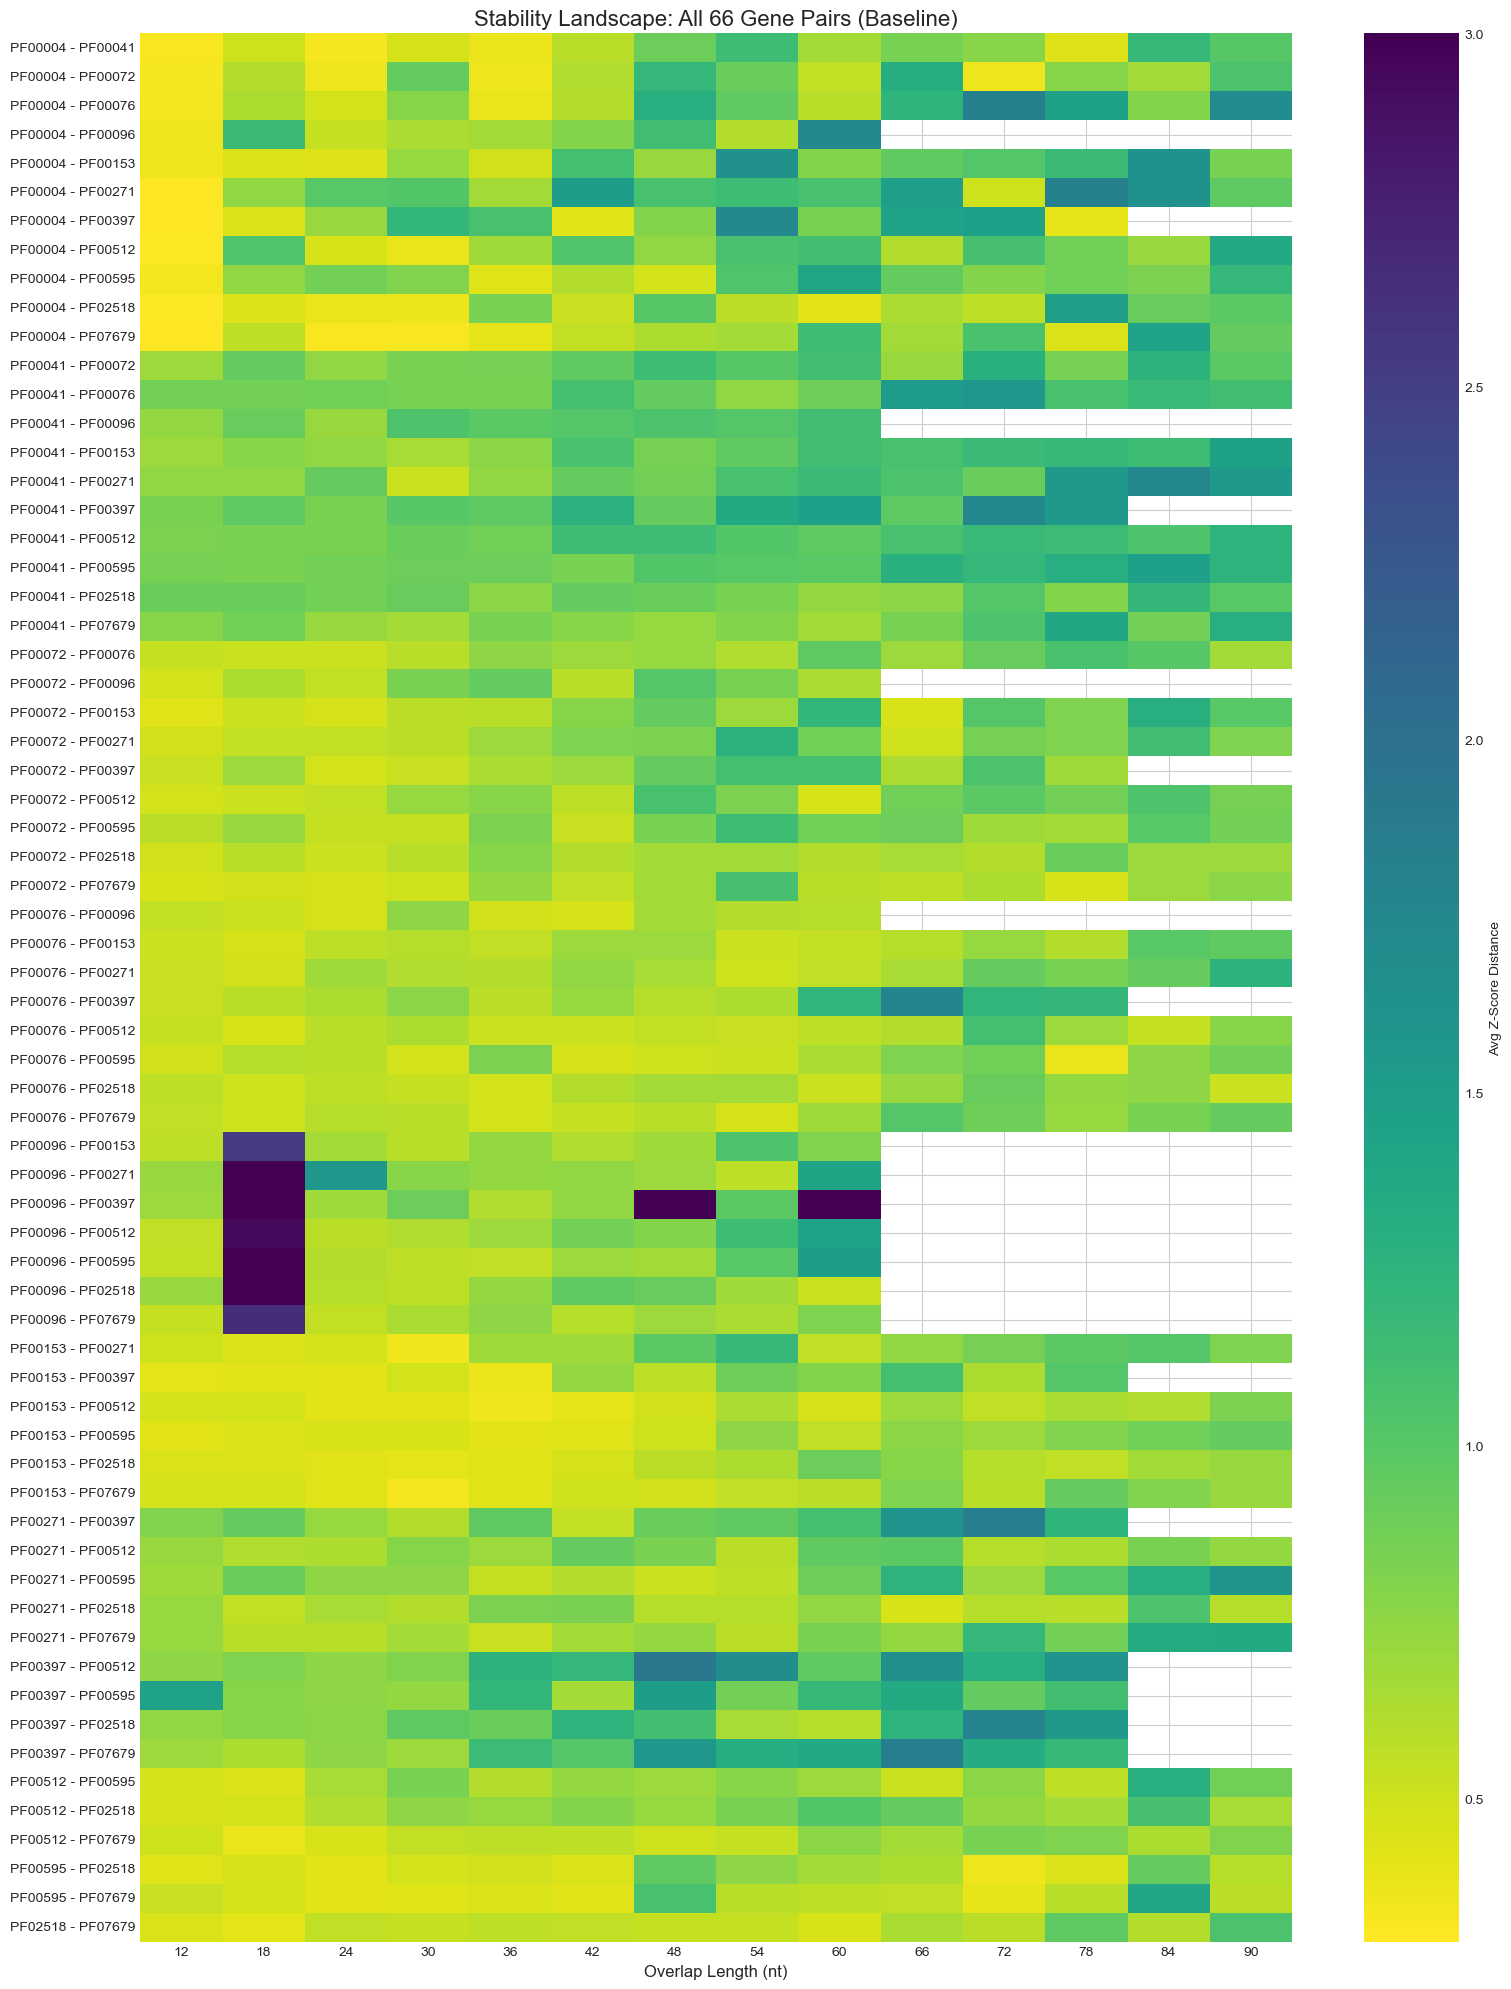

Plotting: Minimum Energy Distance (Best State)


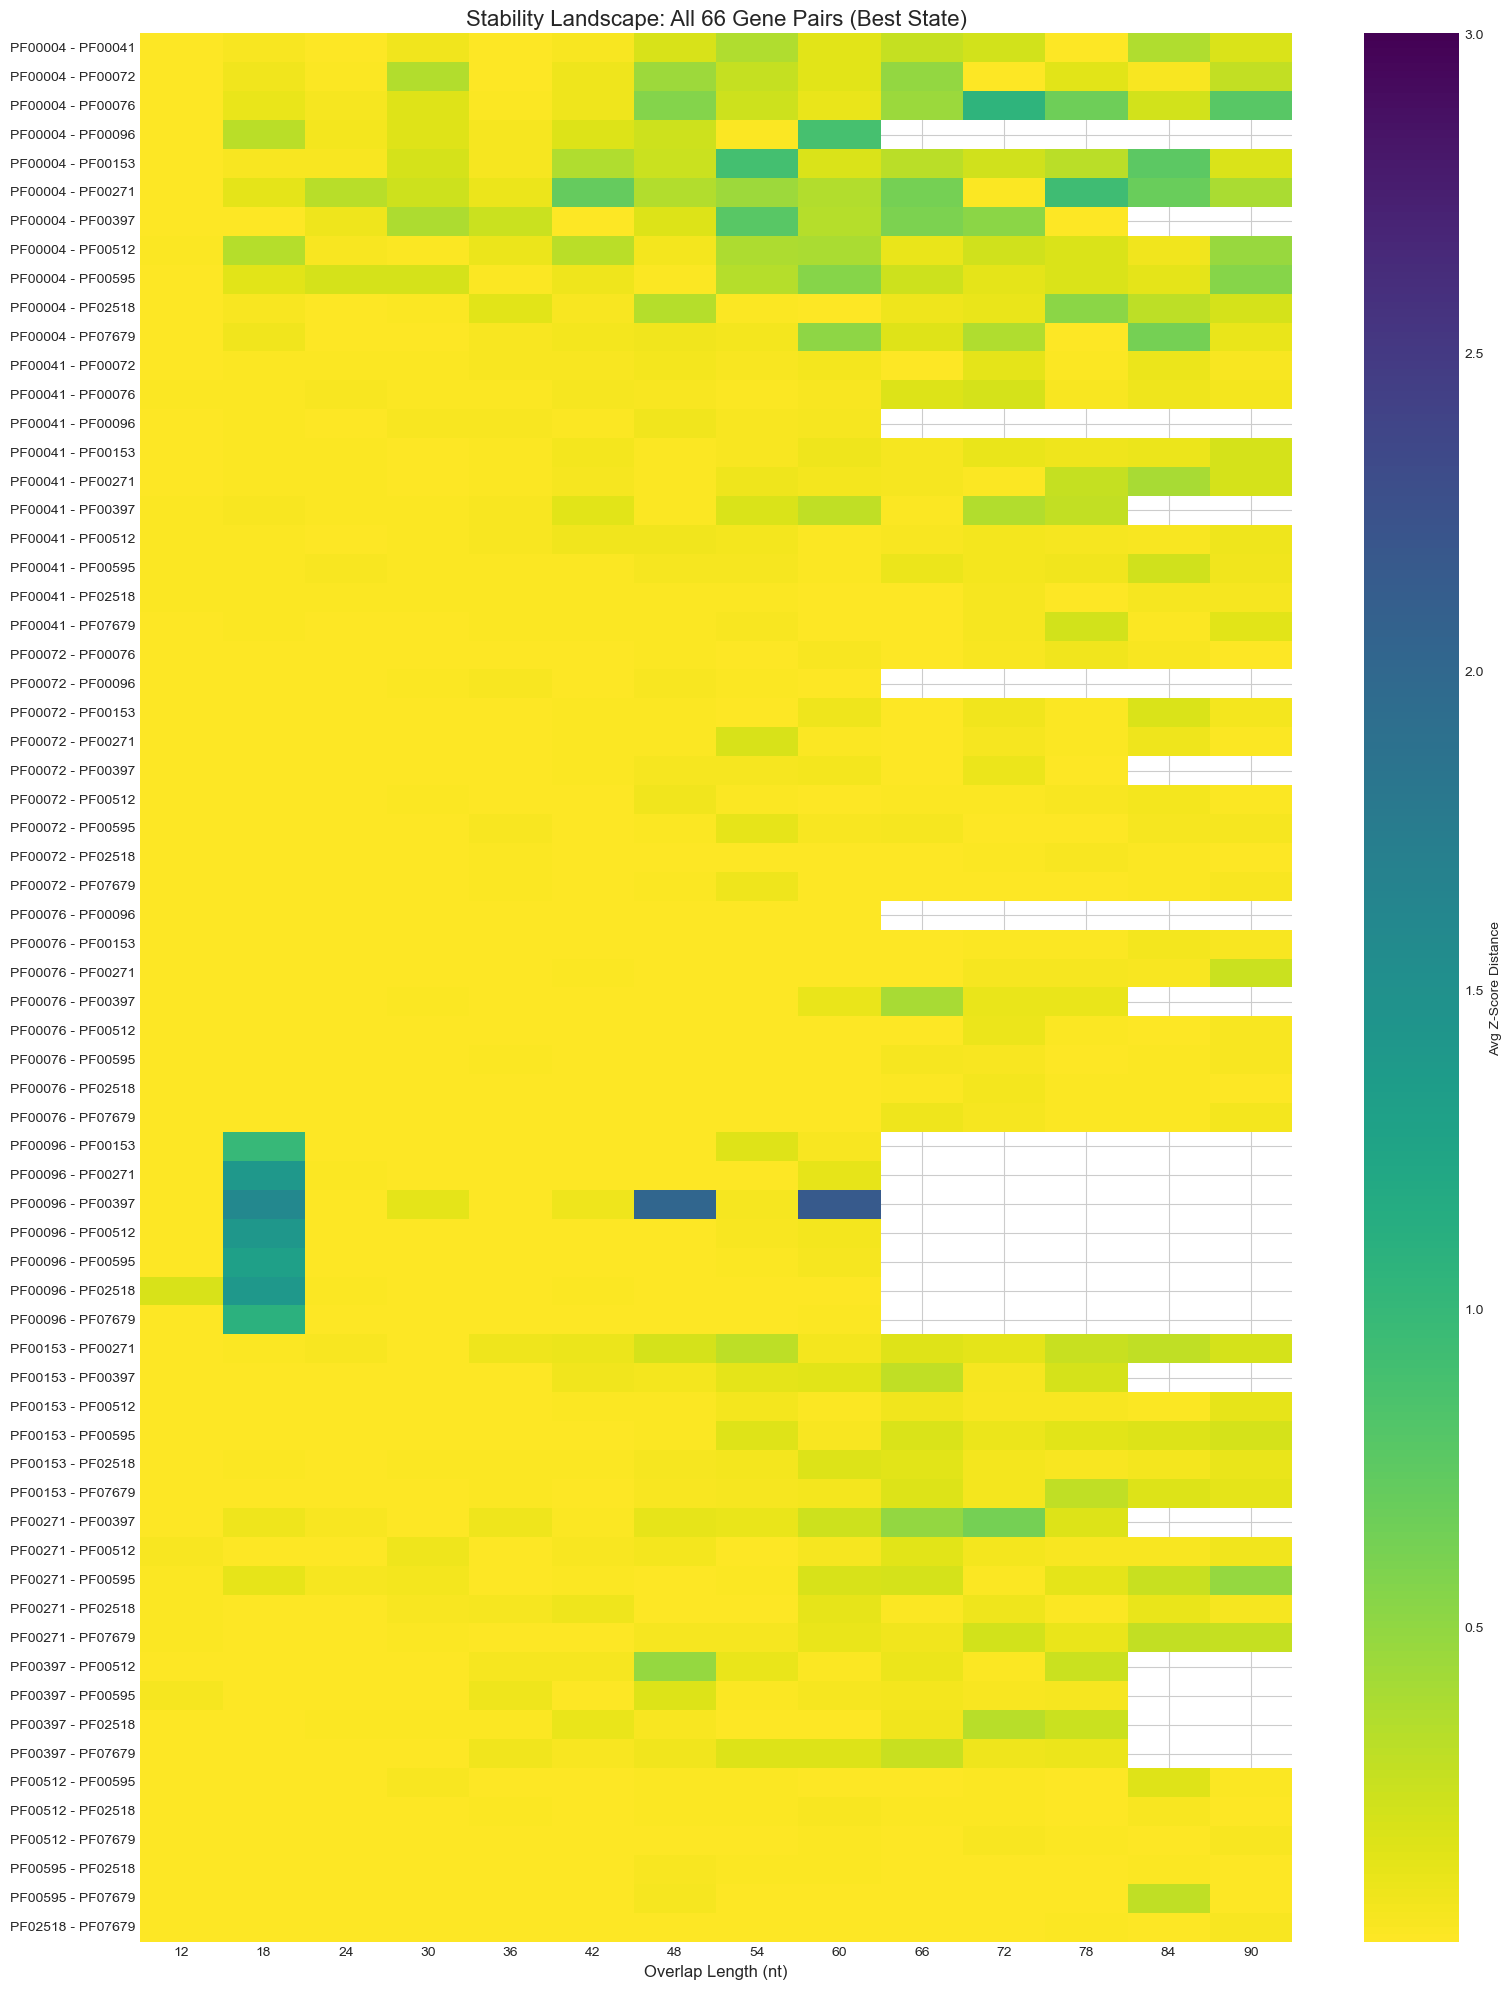

Plotting: Iterations to Convergence (Within 1 Std Dev)


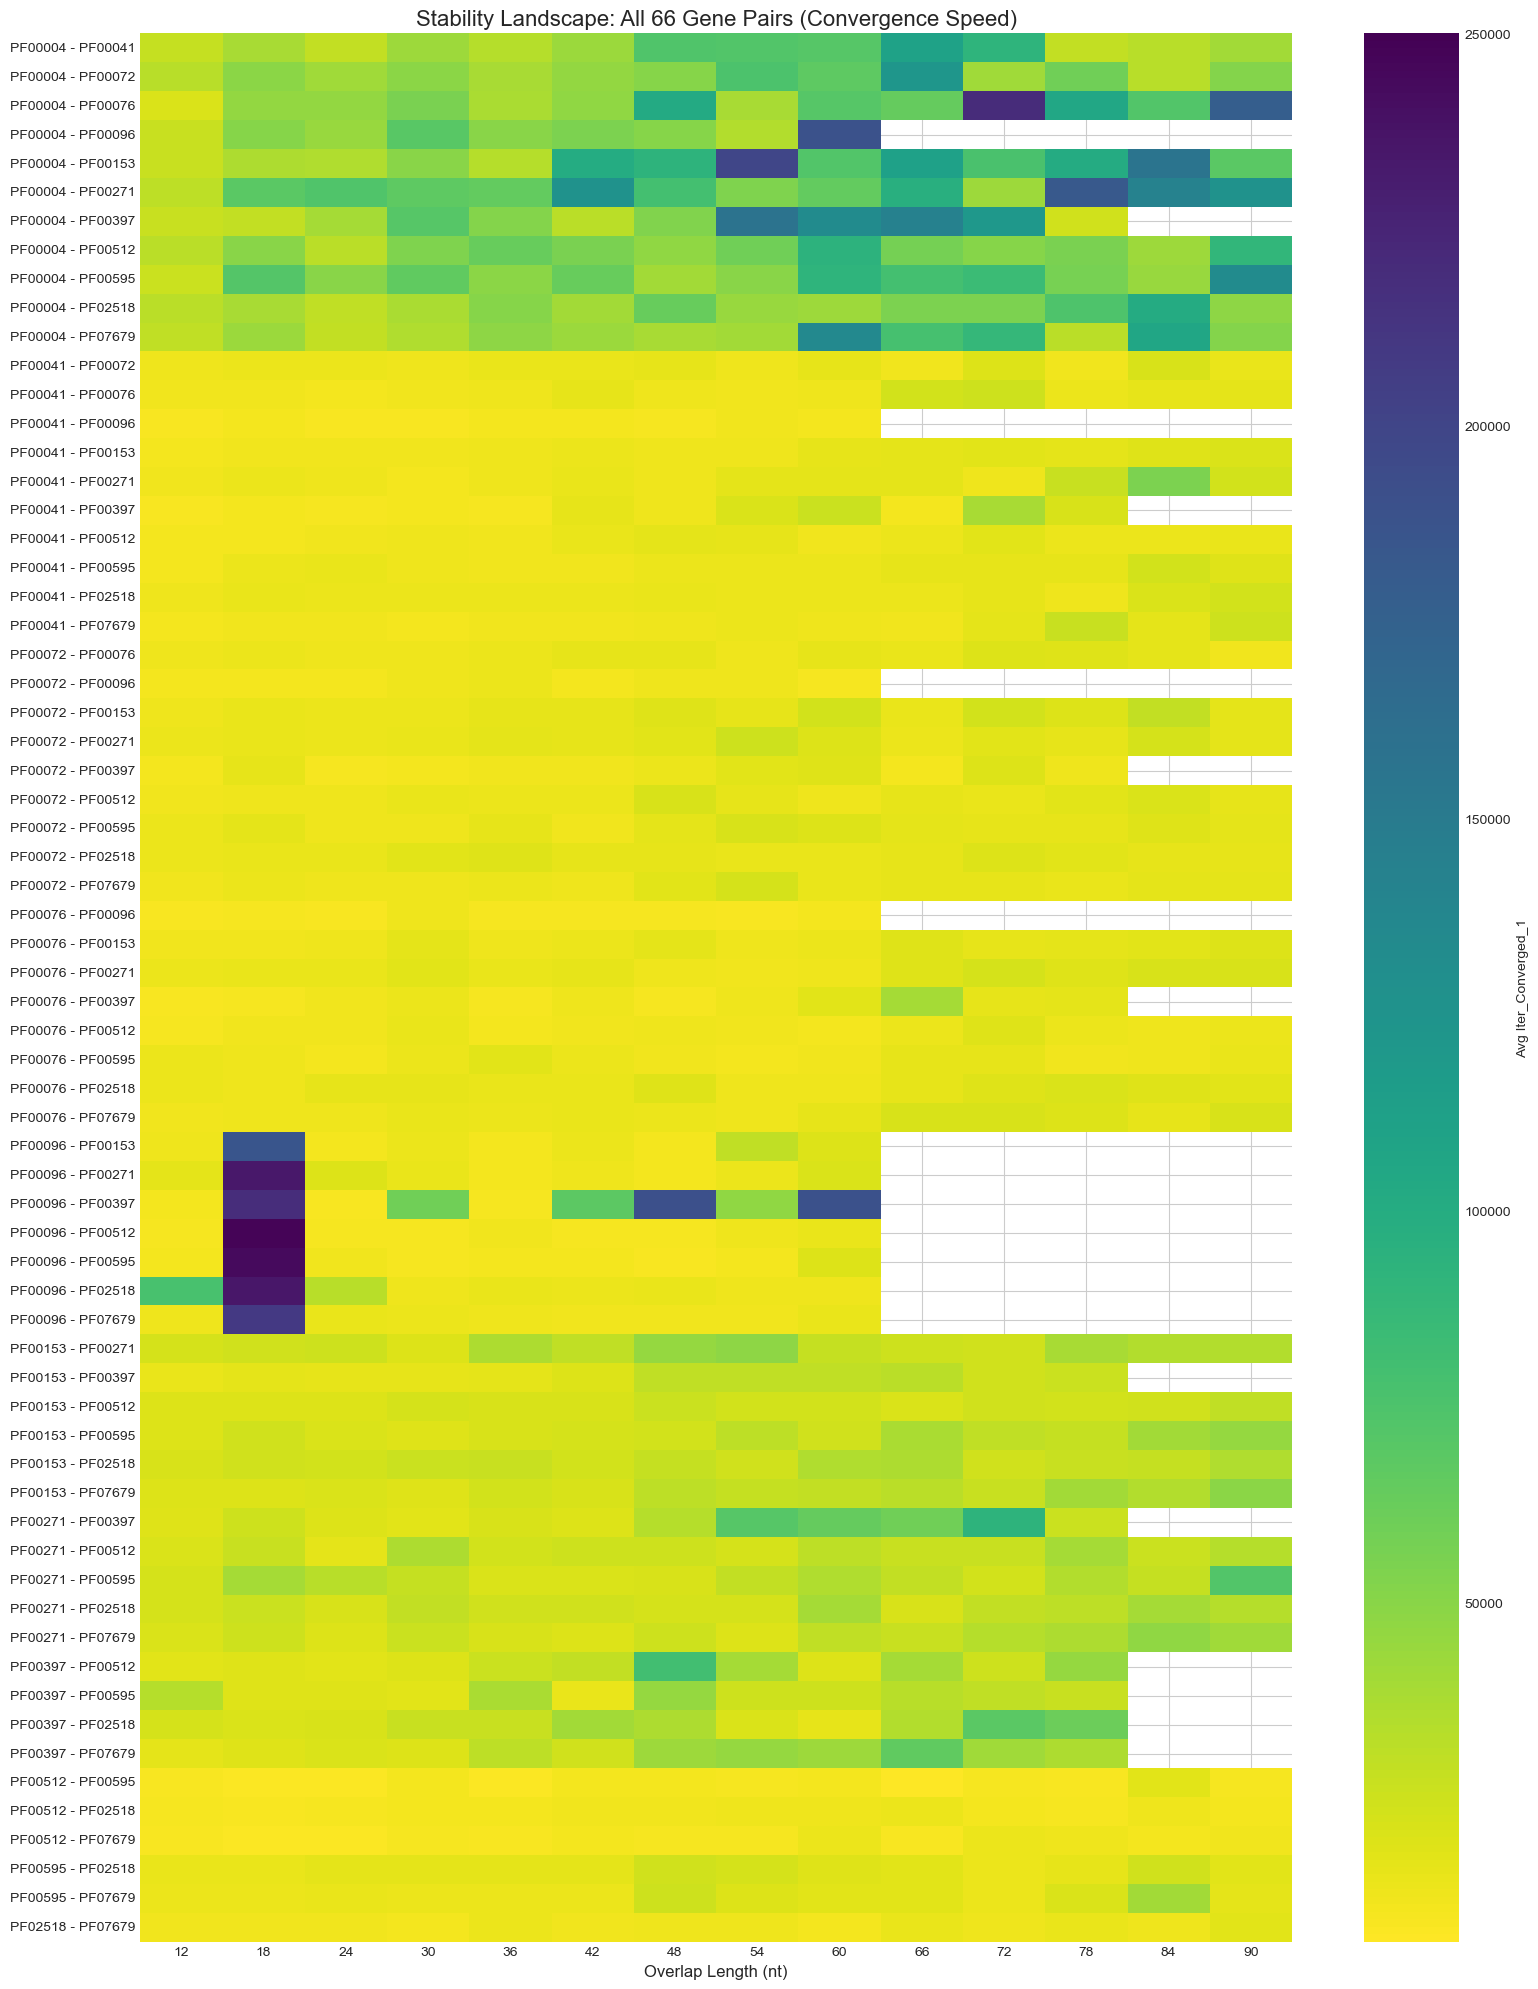

In [10]:
# --- 4. VISUALIZATION (SEABORN) ---

def plot_heatmap(df, metric='Dist_1', title_prefix="", vmax=None):
    # Create a new column 'Pair' for Y-axis labels
    df['Pair'] = df['PF1'] + ' - ' + df['PF2']
    
    # Pivot: Index=Pair, Columns=Overlap Limit, Values=Metric
    pivot = df.pivot_table(index='Pair', columns='Overlap', values=metric)
    
    # Dynamic label based on Z_SCORE setting
    if 'Dist' in metric:
        cbar_label = f'Avg {DIST_LABEL}' if Z_SCORE else f'Avg {metric}'
    else:
        cbar_label = f'Avg {metric}'
    
    plt.figure(figsize=(16, 20))
    sns.heatmap(pivot, 
                cmap="viridis_r", 
                vmax=vmax, 
                cbar_kws={'label': cbar_label})
    
    plt.title(f'Stability Landscape: All {len(pivot)} Gene Pairs ({title_prefix})', fontsize=16)
    plt.xlabel('Overlap Length (nt)', fontsize=12)
    plt.ylabel('')
    plt.tight_layout()
    plt.show()

if 'results_df' in dir():
    print("Plotting: Final Energy Distance (Baseline)")
    plot_heatmap(results_df, metric='Dist_1', title_prefix="Baseline", vmax=3)
    
    print("Plotting: Minimum Energy Distance (Best State)")
    plot_heatmap(results_df, metric='Min_Dist_1', title_prefix="Best State", vmax=3)
    
    print("Plotting: Iterations to Convergence (Within 1 Std Dev)")
    plot_heatmap(results_df, metric='Iter_Converged_1', title_prefix="Convergence Speed", vmax=ITERATIONS)

Loaded results from large_scale_results_refined_std.csv
Plotting: Final Energy Distance (Baseline)


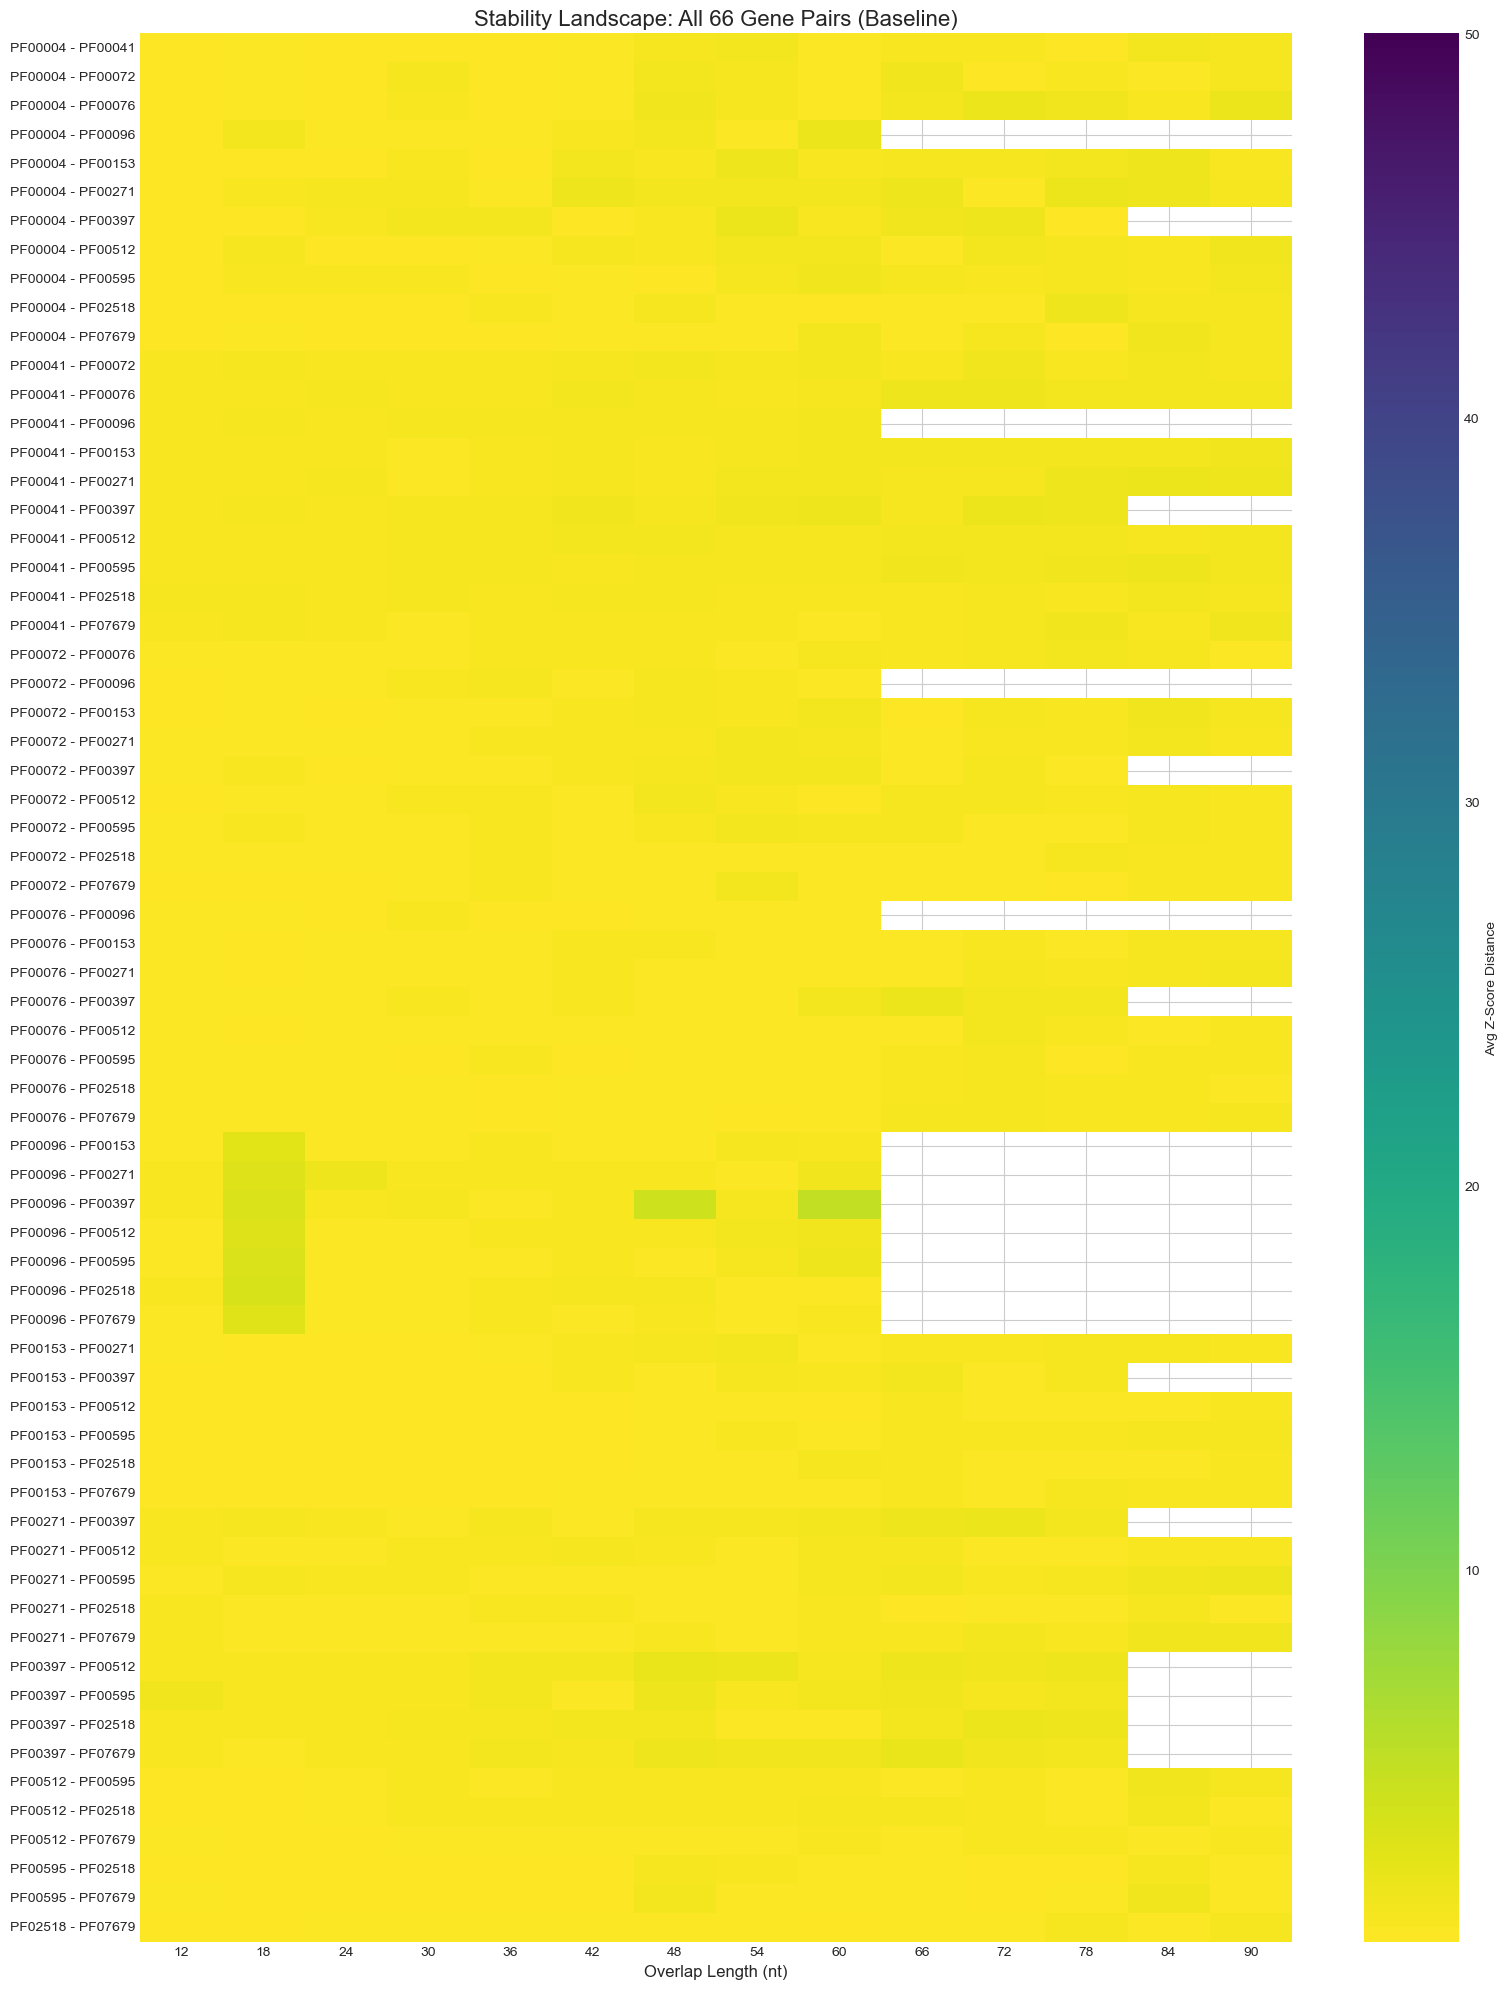

Plotting: Minimum Energy Distance (Best State)


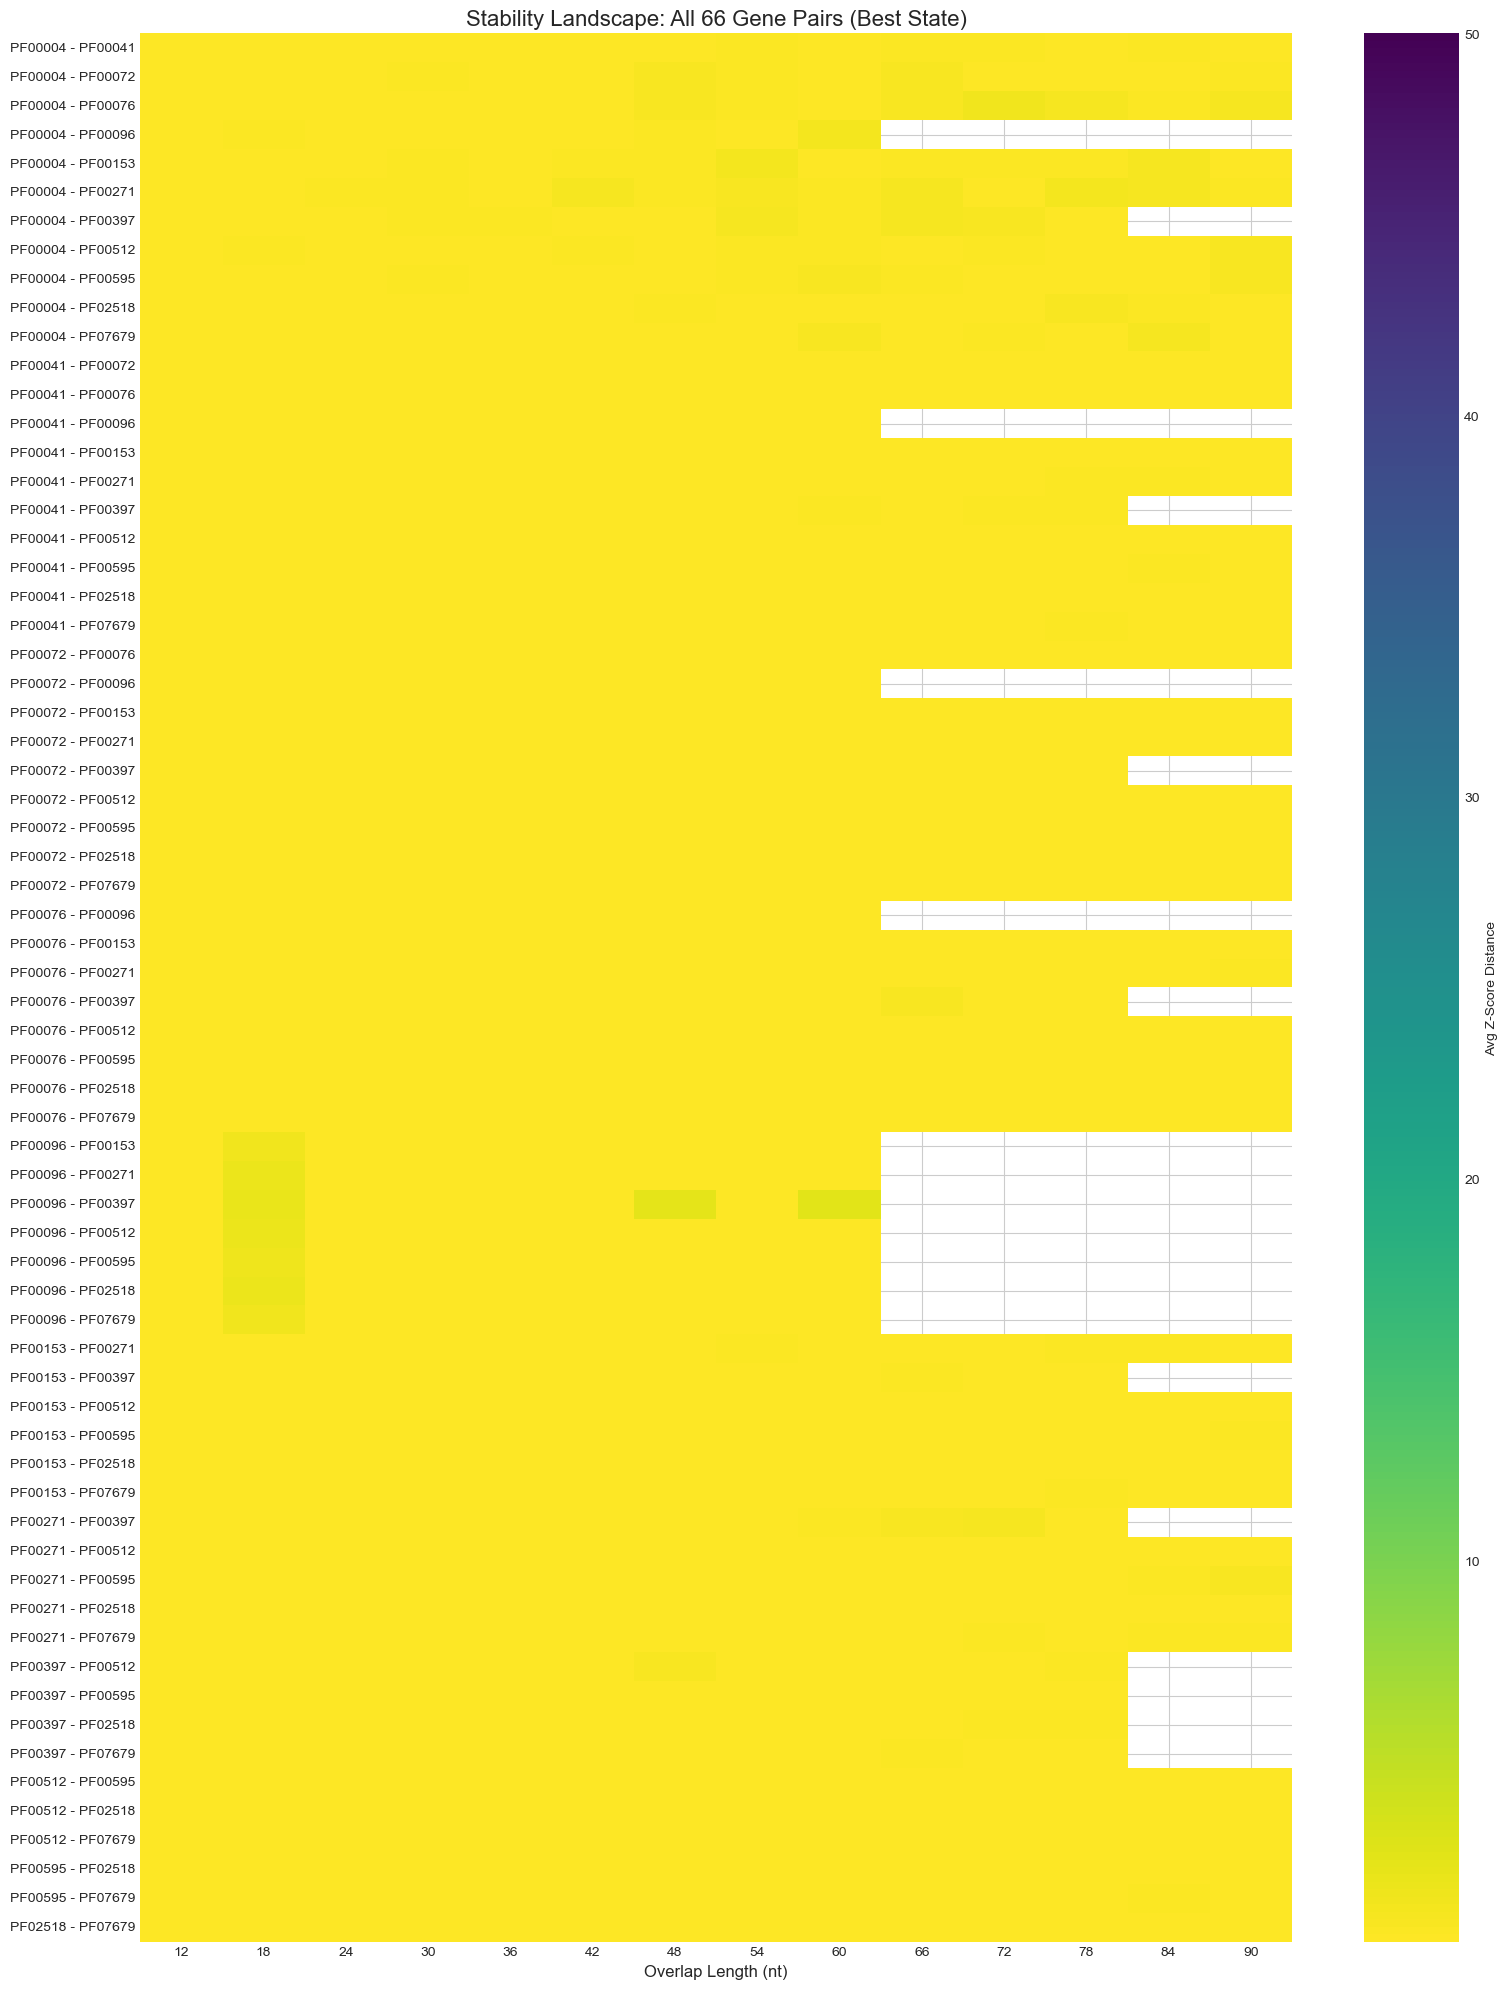

Plotting: Iterations to Convergence


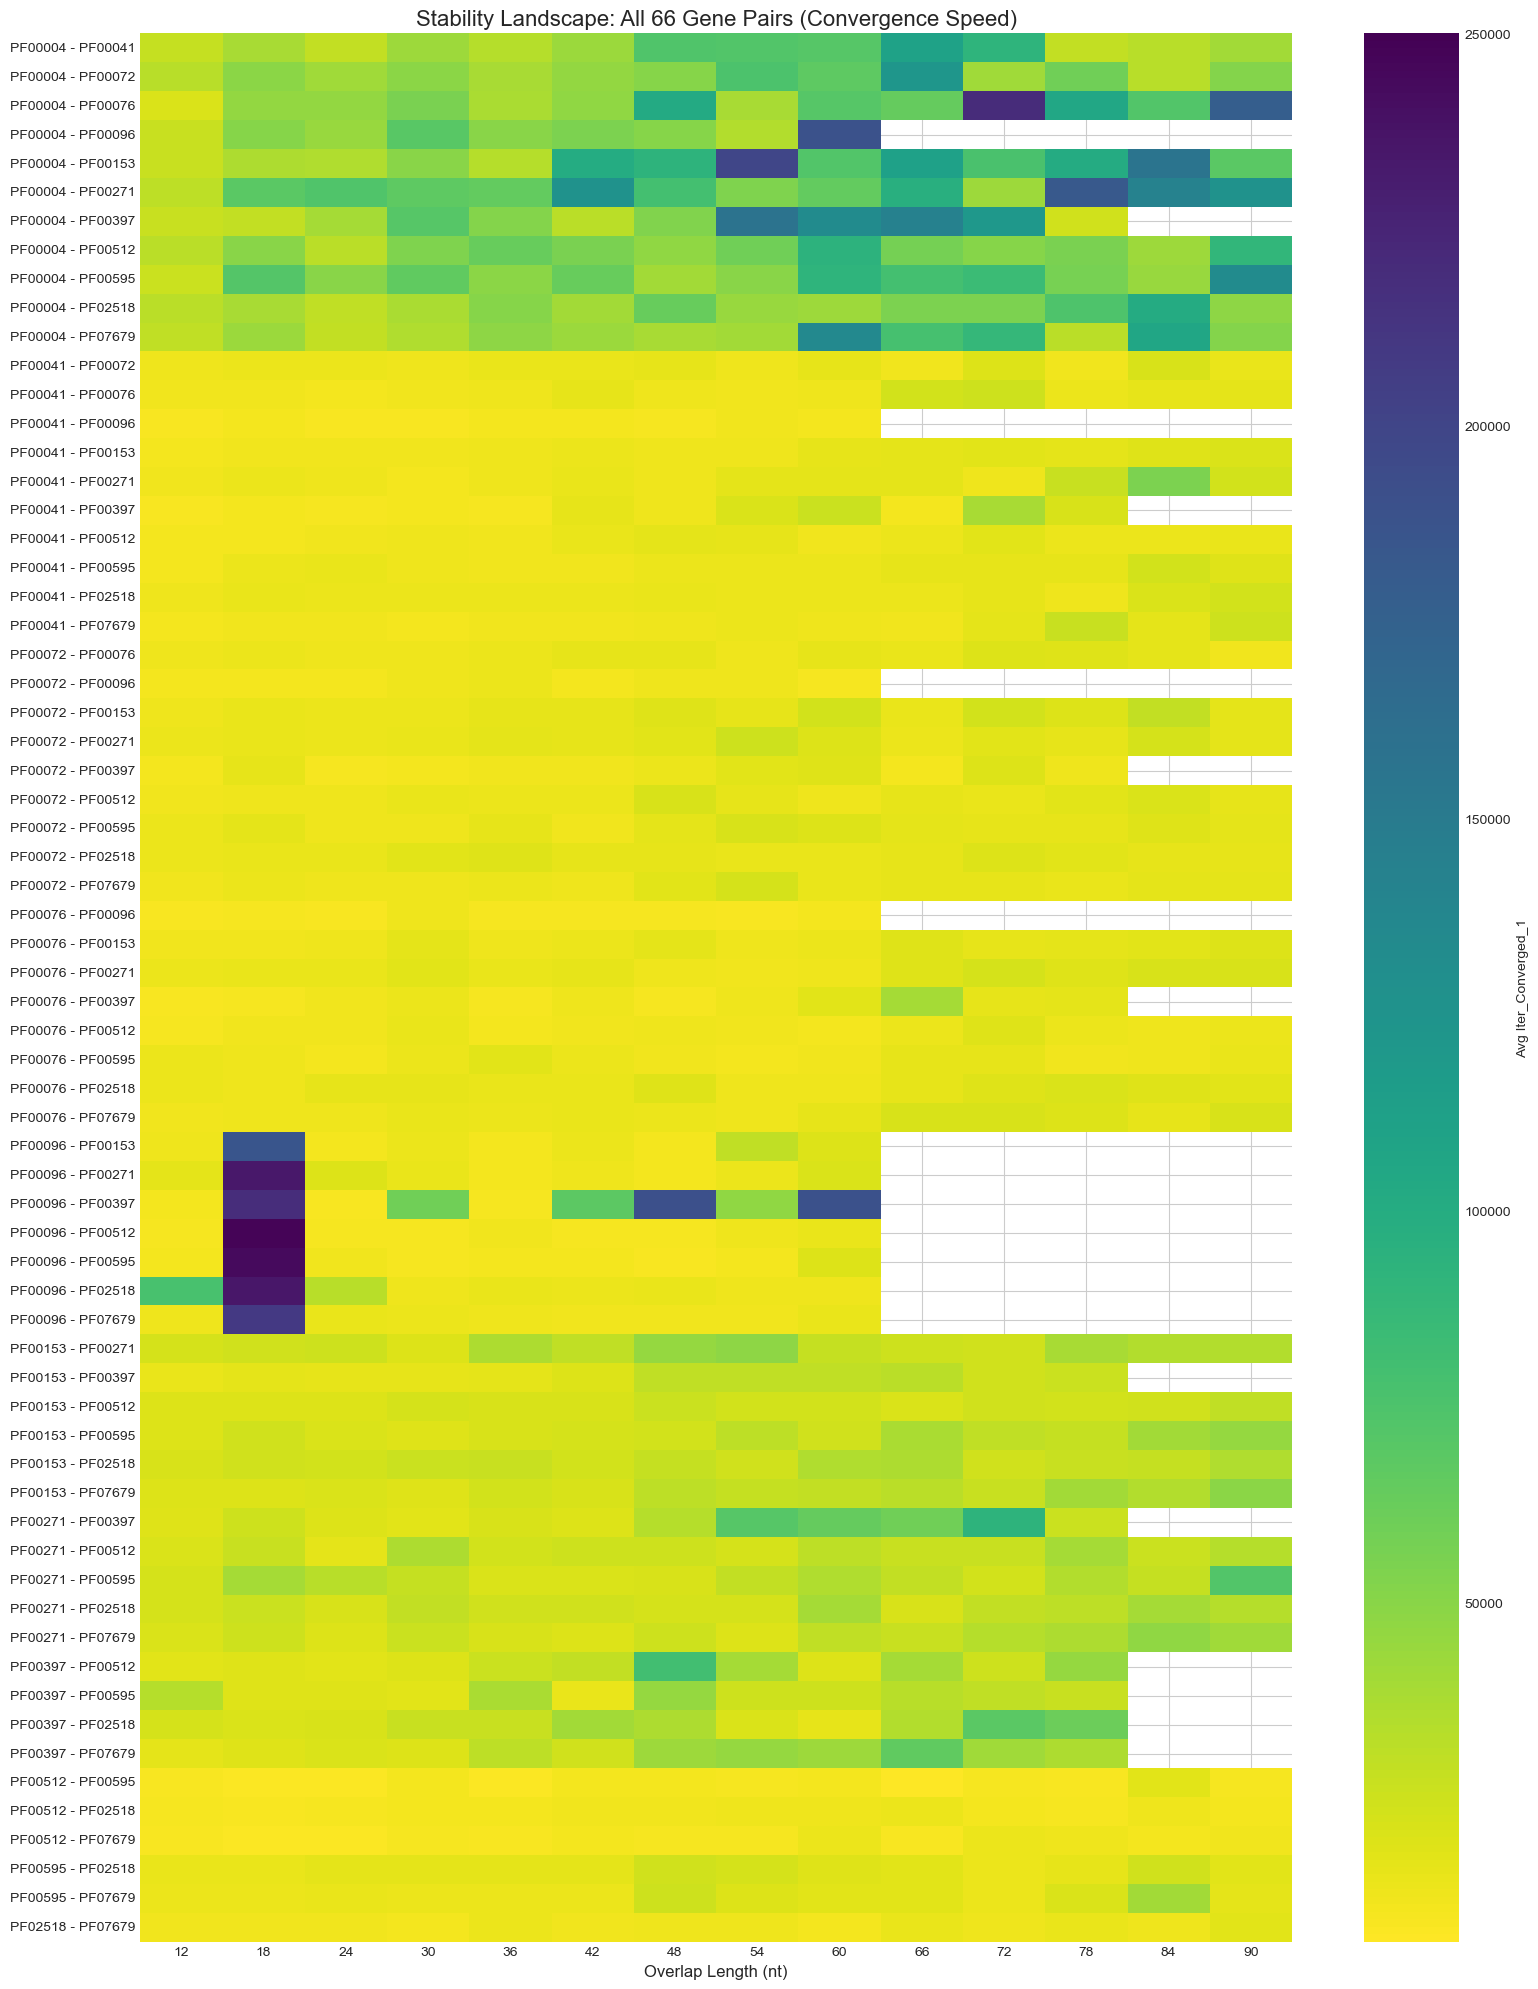

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# 1. Load the Results
# Replace 'large_scale_results_refined_std.csv' with your actual results filename if different
results_file = "large_scale_results_refined_std.csv"

if os.path.exists(results_file):
    results_df = pd.read_csv(results_file)
    print(f"Loaded results from {results_file}")
    
    # 2. Define the Plotting Function
    def plot_heatmap_refined(df, metric, title_prefix="", vmax=None):
        # Create a new column 'Pair' for Y-axis labels
        df['Pair'] = df['PF1'] + ' - ' + df['PF2']
        
        # Pivot: Index=Pair, Columns=Overlap Limit, Values=Metric
        pivot = df.pivot_table(index='Pair', columns='Overlap', values=metric)
        
        # Dynamic label based on Z_SCORE setting
        if 'Dist' in metric:
            cbar_label = f'Avg {DIST_LABEL}' if Z_SCORE else f'Avg {metric}'
        else:
            cbar_label = f'Avg {metric}'
        
        plt.figure(figsize=(16, 20))
        sns.heatmap(pivot, 
                    cmap="viridis_r", 
                    vmax=vmax, 
                    cbar_kws={'label': cbar_label})
        
        plt.title(f'Stability Landscape: All {len(pivot)} Gene Pairs ({title_prefix})', fontsize=16)
        plt.xlabel('Overlap Length (nt)', fontsize=12)
        plt.ylabel('') # Hide Y label as Pair names are enough
        plt.tight_layout()
        plt.show()

    # 3. Generate Plots
    print("Plotting: Final Energy Distance (Baseline)")
    plot_heatmap_refined(results_df, metric='Dist_1', title_prefix="Baseline", vmax=50)

    print("Plotting: Minimum Energy Distance (Best State)")
    plot_heatmap_refined(results_df, metric='Min_Dist_1', title_prefix="Best State", vmax=50)

    # Use a large vmax for iterations (e.g., 250,000) or let it auto-scale
    print("Plotting: Iterations to Convergence")
    plot_heatmap_refined(results_df, metric='Iter_Converged_1', title_prefix="Convergence Speed", vmax=250000)

else:
    print(f"Error: Could not find results file '{results_file}'. Please check the filename.")

MAKE SURE THE WAY THE DISTANCE IS CALCULATED SO THAT AVERAGE DOSTANCE DOESNT CANCEL AND GIVE 0 DISTANCE. LOOOK AT PHOTO OF WHITEBOARD